<a href="https://colab.research.google.com/github/VDP-29-hacher/Biblioth-que-du-Burkina/blob/main/glycemie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Analyse de Glucose Sanguin et Recommandation de Glucides

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le bon fichier contenant les données de glucose et le timestamp
df = pd.read_csv('/content/GlucoBench_benchmark_dataset.csv')

# Convertir la colonne 'timestamp' en format datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Afficher un aperçu des données chargées
print("Aperçu des données GlucoBench :")
display(df.head())

Aperçu des données GlucoBench :


,user_id,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,meal_type,exercise_steps,exercise_intensity,...,sex,weight,carb_ratio,insulin_sensitivity,timezone,region,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_roll_mean_1h
0,U001,2024-09-01 00:00:00,127.0,1,0.0,1.05,0,none,0,none,...,M,79,12,42,America/New_York,USA,NaN,NaN,NaN,127.000000
1,U001,2024-09-01 00:15:00,126.5,1,0.0,0.84,0,none,0,none,...,M,79,12,42,America/New_York,USA,127.0,NaN,NaN,126.750000
2,U001,2024-09-01 00:20:00,126.8,1,0.0,1.19,0,none,0,none,...,M,79,12,42,America/New_York,USA,126.5,NaN,NaN,126.766667
3,U001,2024-09-01 00:25:00,127.2,1,0.0,0.99,0,none,0,none,...,M,79,12,42,America/New_York,USA,126.8,127.0,NaN,126.875000
4,U001,2024-09-01 00:30:00,126.7,1,0.0,1.12,0,none,0,none,...,M,79,12,42,America/New_York,USA,127.2,126.5,NaN,126.840000


In [139]:
print("Statistiques descriptives pour la colonne 'glucose' (GlucoBench) :")
display(df['glucose'].describe())

Statistiques descriptives pour la colonne 'glucose' (GlucoBench) :


,glucose
count,15731.000000
mean,112.690573
std,30.298234
min,70.000000
25%,87.500000
50%,108.000000
75%,131.600000
max,198.400000


## 1. Préparation et Exploration des Données
Avant de construire notre modèle, il est crucial de nettoyer, de comprendre et de préparer nos données. Cela inclut la gestion des valeurs manquantes, la conversion des types de données, et l'ingénierie de fonctionnalités pertinentes.

In [140]:
# Vérifier les informations sur le DataFrame
print("Informations sur le DataFrame:")
df.info()

# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne:")
display(df.isnull().sum())

# Description statistique des colonnes numériques
print("\nDescription statistique des colonnes numériques:")
display(df.describe())

Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15731 entries, 0 to 15730
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               15731 non-null  object        
 1   timestamp             15731 non-null  datetime64[ns]
 2   glucose               15731 non-null  float64       
 3   cgm_quality_flag      15731 non-null  int64         
 4   insulin_bolus         15731 non-null  float64       
 5   insulin_basal         15731 non-null  float64       
 6   carbs                 15731 non-null  int64         
 7   meal_type             15731 non-null  object        
 8   exercise_steps        15731 non-null  int64         
 9   exercise_intensity    15731 non-null  object        
 10  heart_rate            15731 non-null  float64       
 11  skin_temp             15731 non-null  float64       
 12  gsr                   15731 non-null  float

,0
user_id,0
timestamp,0
glucose,0
cgm_quality_flag,0
insulin_bolus,0
insulin_basal,0
carbs,0
meal_type,0
exercise_steps,0
exercise_intensity,0



Description statistique des colonnes numériques:


,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,exercise_steps,heart_rate,skin_temp,gsr,...,notes,hbA1c,age,weight,carb_ratio,insulin_sensitivity,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_roll_mean_1h
count,15731,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,...,0.0,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15721.000000,15701.000000,15671.000000,15731.000000
mean,2024-09-05 11:43:40.628059392,112.690573,0.989257,0.248058,0.999924,2.955947,75.439006,85.230602,36.503388,1.496921,...,NaN,7.271489,42.645159,79.665183,10.998093,47.819274,112.681528,112.663308,112.635154,112.636773
min,2024-09-01 00:00:00,70.000000,0.000000,0.000000,0.800000,0.000000,0.000000,60.000000,35.500000,0.500000,...,NaN,6.100000,19.000000,51.000000,9.000000,40.000000,70.000000,70.000000,70.000000,70.000000
25%,2024-09-03 06:07:30,87.500000,1.000000,0.000000,0.900000,0.000000,0.000000,72.500000,36.000000,0.990000,...,NaN,6.600000,24.000000,60.000000,9.000000,44.000000,87.500000,87.500000,87.500000,87.533333
50%,2024-09-05 11:40:00,108.000000,1.000000,0.000000,1.000000,0.000000,0.000000,85.300000,36.500000,1.490000,...,NaN,7.500000,35.000000,79.000000,10.000000,48.000000,108.000000,108.000000,108.000000,107.900000
75%,2024-09-07 17:47:30,131.600000,1.000000,0.000000,1.100000,0.000000,0.000000,97.900000,37.000000,2.000000,...,NaN,7.900000,61.000000,99.000000,12.000000,52.000000,131.600000,131.600000,131.600000,131.316667
max,2024-09-09 22:20:00,198.400000,1.000000,11.000000,1.200000,90.000000,4952.000000,110.000000,37.500000,2.500000,...,NaN,8.300000,70.000000,99.000000,15.000000,55.000000,198.400000,198.400000,198.400000,197.500000
std,NaN,30.298234,0.103094,1.244924,0.114740,13.695556,492.802043,14.525513,0.576721,0.580249,...,NaN,0.695829,18.933509,18.213838,1.898940,4.754809,30.292665,30.281708,30.264491,30.196820


Commençons par re-vérifier les informations sur le DataFrame, maintenant que `df` est censé être chargé, puis nous passerons à l'ingénierie de caractéristiques et à l'encodage des variables catégorielles.

In [141]:
# Vérifier les informations sur le DataFrame (à nouveau pour s'assurer que df est défini)
print("Informations sur le DataFrame après s'être assuré de sa création:")
df.info()

# Vérifier les valeurs manquantes (à nouveau)
print("\nValeurs manquantes par colonne après s'être assuré de sa création:")
display(df.isnull().sum())

# Description statistique des colonnes numériques (à nouveau)
print("\nDescription statistique des colonnes numériques après s'être assuré de sa création:")
display(df.describe())

Informations sur le DataFrame après s'être assuré de sa création:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15731 entries, 0 to 15730
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               15731 non-null  object        
 1   timestamp             15731 non-null  datetime64[ns]
 2   glucose               15731 non-null  float64       
 3   cgm_quality_flag      15731 non-null  int64         
 4   insulin_bolus         15731 non-null  float64       
 5   insulin_basal         15731 non-null  float64       
 6   carbs                 15731 non-null  int64         
 7   meal_type             15731 non-null  object        
 8   exercise_steps        15731 non-null  int64         
 9   exercise_intensity    15731 non-null  object        
 10  heart_rate            15731 non-null  float64       
 11  skin_temp             15731 non-null  float64       
 12  gsr     

,0
user_id,0
timestamp,0
glucose,0
cgm_quality_flag,0
insulin_bolus,0
insulin_basal,0
carbs,0
meal_type,0
exercise_steps,0
exercise_intensity,0



Description statistique des colonnes numériques après s'être assuré de sa création:


,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,exercise_steps,heart_rate,skin_temp,gsr,...,notes,hbA1c,age,weight,carb_ratio,insulin_sensitivity,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_roll_mean_1h
count,15731,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,...,0.0,15731.000000,15731.000000,15731.000000,15731.000000,15731.000000,15721.000000,15701.000000,15671.000000,15731.000000
mean,2024-09-05 11:43:40.628059392,112.690573,0.989257,0.248058,0.999924,2.955947,75.439006,85.230602,36.503388,1.496921,...,NaN,7.271489,42.645159,79.665183,10.998093,47.819274,112.681528,112.663308,112.635154,112.636773
min,2024-09-01 00:00:00,70.000000,0.000000,0.000000,0.800000,0.000000,0.000000,60.000000,35.500000,0.500000,...,NaN,6.100000,19.000000,51.000000,9.000000,40.000000,70.000000,70.000000,70.000000,70.000000
25%,2024-09-03 06:07:30,87.500000,1.000000,0.000000,0.900000,0.000000,0.000000,72.500000,36.000000,0.990000,...,NaN,6.600000,24.000000,60.000000,9.000000,44.000000,87.500000,87.500000,87.500000,87.533333
50%,2024-09-05 11:40:00,108.000000,1.000000,0.000000,1.000000,0.000000,0.000000,85.300000,36.500000,1.490000,...,NaN,7.500000,35.000000,79.000000,10.000000,48.000000,108.000000,108.000000,108.000000,107.900000
75%,2024-09-07 17:47:30,131.600000,1.000000,0.000000,1.100000,0.000000,0.000000,97.900000,37.000000,2.000000,...,NaN,7.900000,61.000000,99.000000,12.000000,52.000000,131.600000,131.600000,131.600000,131.316667
max,2024-09-09 22:20:00,198.400000,1.000000,11.000000,1.200000,90.000000,4952.000000,110.000000,37.500000,2.500000,...,NaN,8.300000,70.000000,99.000000,15.000000,55.000000,198.400000,198.400000,198.400000,197.500000
std,NaN,30.298234,0.103094,1.244924,0.114740,13.695556,492.802043,14.525513,0.576721,0.580249,...,NaN,0.695829,18.933509,18.213838,1.898940,4.754809,30.292665,30.281708,30.264491,30.196820


### 2. Ingénierie de Caractéristiques
Créons de nouvelles caractéristiques à partir de la colonne `Date` et `Time_of_Day` pour enrichir notre modèle. Nous allons extraire des informations temporelles et convertir les catégories en formats numériques.

In [142]:
# Extraction de caractéristiques temporelles
df['Year'] = df['timestamp'].dt.year
df['Month'] = df['timestamp'].dt.month
df['Day'] = df['timestamp'].dt.day
df['Day_of_Week'] = df['timestamp'].dt.dayofweek # Lundi=0, Dimanche=6
df['Week_of_Year'] = df['timestamp'].dt.isocalendar().week.astype(int)

# Afficher les premières lignes avec les nouvelles caractéristiques
print("Aperçu des données avec les caractéristiques temporelles ajoutées:")
display(df.head())

Aperçu des données avec les caractéristiques temporelles ajoutées:


,user_id,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,meal_type,exercise_steps,exercise_intensity,...,region,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_roll_mean_1h,Year,Month,Day,Day_of_Week,Week_of_Year
0,U001,2024-09-01 00:00:00,127.0,1,0.0,1.05,0,none,0,none,...,USA,NaN,NaN,NaN,127.000000,2024,9,1,6,35
1,U001,2024-09-01 00:15:00,126.5,1,0.0,0.84,0,none,0,none,...,USA,127.0,NaN,NaN,126.750000,2024,9,1,6,35
2,U001,2024-09-01 00:20:00,126.8,1,0.0,1.19,0,none,0,none,...,USA,126.5,NaN,NaN,126.766667,2024,9,1,6,35
3,U001,2024-09-01 00:25:00,127.2,1,0.0,0.99,0,none,0,none,...,USA,126.8,127.0,NaN,126.875000,2024,9,1,6,35
4,U001,2024-09-01 00:30:00,126.7,1,0.0,1.12,0,none,0,none,...,USA,127.2,126.5,NaN,126.840000,2024,9,1,6,35


### 3.1 Ingénierie de Caractéristiques Avancée (Lag Features et Moyennes Mobiles)

Pour les données temporelles, les "lag features" (valeurs décalées) et les moyennes mobiles sont essentielles. Elles permettent au modèle de prendre en compte les observations passées des niveaux de glucose et de l'apport en glucides pour prédire l'apport futur. De plus, il est crucial d'inclure la colonne `Glucose_Level` comme caractéristique (`X`), car elle est un prédicteur direct de `Carb_Intake_g`.

Avant de créer ces caractéristiques, nous nous assurons que le DataFrame est trié chronologiquement pour que les décalages soient corrects.

In [143]:
# S'assurer que les données sont triées chronologiquement avant de créer des lag features
df.sort_values(by=['timestamp'], inplace=True)

# Créer des lag features pour les niveaux de glucose et l'apport en glucides
# 'shift(1)' prend la valeur de l'observation précédente
df['glucose_lag1'] = df['glucose'].shift(1)
df['carbs_lag1'] = df['carbs'].shift(1)

# Créer une moyenne mobile pour les niveaux de glucose (sur les 3 dernières observations)
df['glucose_rolling_mean_3'] = df['glucose'].rolling(window=3, min_periods=1).mean().shift(1)

# Créer des caractéristiques de variation de la glycémie
df['glucose_diff1'] = df['glucose'].diff(1)
df['glucose_diff2'] = df['glucose'].diff(2)
df['glucose_rate_of_change'] = df['glucose'].pct_change(1)

# Supprimer les lignes avec des valeurs NaN introduites par les lag et diff features
# Ces NaN apparaissent au début de la série pour lesquelles il n'y a pas d'observations précédentes
df_cleaned = df.dropna()

print("Aperçu des données avec les nouvelles caractéristiques lag, rolling et variation (après suppression des NaN) :")
display(df_cleaned.head())
print(f"Nouvelle taille du DataFrame après suppression des NaN : {df_cleaned.shape[0]} échantillons")

# Mettre à jour l'information du DataFrame nettoyé
print("\nInformations sur le DataFrame nettoyé après ingénierie de caractéristiques avancée :")
df_cleaned.info()

Aperçu des données avec les nouvelles caractéristiques lag, rolling et variation (après suppression des NaN) :


,user_id,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,meal_type,exercise_steps,exercise_intensity,...,Month,Day,Day_of_Week,Week_of_Year,glucose_lag1,carbs_lag1,glucose_rolling_mean_3,glucose_diff1,glucose_diff2,glucose_rate_of_change


Nouvelle taille du DataFrame après suppression des NaN : 0 échantillons

Informations sur le DataFrame nettoyé après ingénierie de caractéristiques avancée :
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   user_id                 0 non-null      object        
 1   timestamp               0 non-null      datetime64[ns]
 2   glucose                 0 non-null      float64       
 3   cgm_quality_flag        0 non-null      int64         
 4   insulin_bolus           0 non-null      float64       
 5   insulin_basal           0 non-null      float64       
 6   carbs                   0 non-null      int64         
 7   meal_type               0 non-null      object        
 8   exercise_steps          0 non-null      int64         
 9   exercise_intensity      0 non-null      object        
 10  heart_rate              0 non

In [144]:
# One-Hot Encoding pour les variables catégorielles pertinentes du nouveau dataset
# Utiliser les colonnes 'meal_type' et 'exercise_intensity' comme substituts à 'Time_of_Day' et 'Activity_Level'
# Nous devons re-créer df_cleaned avec une stratégie de gestion des NaN plus adaptée si dropna() vide le DataFrame.

# La cellule précédente (119d5933) a vide df_cleaned si elle contenait des NaN.
# Une stratégie alternative est d'imputer les NaN ou de les gérer différemment.
# Pour l'instant, réexécutons simplement sans vider le DataFrame si possible.

# Avant d'appliquer get_dummies, gérons les NaN de df afin de ne pas vider le DataFrame.
# Pour les colonnes numériques, nous pouvons imputer avec la moyenne ou la médiane.
# Pour les colonnes catégorielles, nous pouvons utiliser le mode ou une catégorie 'missing'.

# Identification des colonnes avec des NaN qui ont causé le problème dans df_cleaned
# Basé sur df.info() de 8fd68022, les colonnes avec NaN sont 'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6', 'notes'.
# 'notes' est entièrement vide, donc il sera probablement supprimé ou ignoré.
# Les 'glucose_lag_X' sont introduits par .shift() et sont peu nombreux.

# Nous allons imputer les NaN pour les colonnes numériques créées par les lags et diff
for col in ['glucose_lag1', 'carbs_lag1', 'glucose_rolling_mean_3', 'glucose_diff1', 'glucose_diff2', 'glucose_rate_of_change']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean()) # Imputation par la moyenne

# Gérer les autres colonnes potentiellement NaN si elles sont utilisées comme caractéristiques
# Supposons pour l'instant que 'notes' ne sera pas utilisé.

# Définir les colonnes catégorielles à encoder
categorical_cols_to_encode = ['meal_type', 'exercise_intensity', 'sleep_stage', 'sex', 'timezone', 'region']

# Filtrer uniquement les colonnes catégorielles qui existent réellement dans le DataFrame
existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

# Appliquer One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)

# Afficher les premières lignes après encodage
print("Aperçu des données après encodage des variables catégorielles:")
display(df_encoded.head())

# Vérifier les informations pour voir les nouvelles colonnes
print("\nInformations sur le DataFrame après encodage:")
df_encoded.info()

Aperçu des données après encodage des variables catégorielles:


,user_id,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,exercise_steps,heart_rate,skin_temp,...,exercise_intensity_low,exercise_intensity_medium,exercise_intensity_none,sleep_stage_awake,sleep_stage_deep,sleep_stage_light,sex_M,timezone_America/New_York,timezone_Europe/London,region_USA
0,U001,2024-09-01,127.0,1,0.0,1.05,0,0,102.8,35.7,...,False,False,True,True,False,False,True,True,False,True
11041,U008,2024-09-01,129.6,1,0.0,0.98,0,0,72.8,37.3,...,False,False,True,False,True,False,True,False,False,True
3137,U003,2024-09-01,101.0,1,0.0,1.03,0,0,108.8,35.8,...,False,False,True,True,False,False,True,True,False,True
4724,U004,2024-09-01,128.3,1,0.0,0.97,0,0,63.6,36.9,...,False,False,True,False,True,False,False,True,False,True
7908,U006,2024-09-01,115.4,1,0.0,0.86,0,0,63.3,35.9,...,False,False,True,False,False,False,True,True,False,True



Informations sur le DataFrame après encodage:
<class 'pandas.core.frame.DataFrame'>
Index: 15731 entries, 0 to 15730
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   user_id                    15731 non-null  object        
 1   timestamp                  15731 non-null  datetime64[ns]
 2   glucose                    15731 non-null  float64       
 3   cgm_quality_flag           15731 non-null  int64         
 4   insulin_bolus              15731 non-null  float64       
 5   insulin_basal              15731 non-null  float64       
 6   carbs                      15731 non-null  int64         
 7   exercise_steps             15731 non-null  int64         
 8   heart_rate                 15731 non-null  float64       
 9   skin_temp                  15731 non-null  float64       
 10  gsr                        15731 non-null  float64       
 11  medication_other         

### 4. Préparation pour la Modélisation

Maintenant que nos données sont nettoyées et que de nouvelles caractéristiques ont été créées, nous devons préparer les ensembles d'entraînement et de test. Nous allons définir notre variable cible (`y`) et nos caractéristiques (`X`), puis diviser les données pour l'apprentissage et l'évaluation.

In [145]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create a copy to avoid SettingWithCopyWarning and ensure changes are localized
df_processed = df_encoded.copy()

# Imputer les NaNs dans toutes les colonnes numériques avec leur moyenne
# Cela couvre à la fois les colonnes originales avec NaNs et celles créées par l'ingénierie de caractéristiques
for col in df_processed.select_dtypes(include=np.number).columns:
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

# Identifier les colonnes qui sont entièrement NaN (comme 'notes') et les supprimer
cols_to_drop_full_nan = df_processed.columns[df_processed.isnull().all()].tolist()
if cols_to_drop_full_nan:
    print(f"Dropping columns with all NaN values: {cols_to_drop_full_nan}")
    df_processed = df_processed.drop(columns=cols_to_drop_full_nan)

# Define the target variable
y = df_processed['carbs']

# Define the features (X) by dropping columns that are not suitable for modeling
columns_to_drop = [
    'timestamp',
    'user_id',
    'device_id',
    'medication_other', # Dropping if it's an object type and not useful as a raw string
    'glucose', # The current glucose level, using lagged features instead
    'carbs' # The target variable itself
]

# Ensure only existing columns are dropped from the features set
X = df_processed.drop(columns=[col for col in columns_to_drop if col in df_processed.columns], axis=1)

# Final check for any remaining NaNs in X before splitting
# If any NaNs remain (e.g., from object columns not handled or edge cases), drop the rows.
if X.isnull().sum().sum() > 0:
    print(f"WARNING: X still contains {X.isnull().sum().sum()} NaN values after preprocessing. Dropping rows with NaNs.")
    original_rows = X.shape[0]
    X = X.dropna()
    y = y.loc[X.index] # Ensure y matches X after dropping rows
    print(f"Dropped {original_rows - X.shape[0]} rows due to remaining NaNs.")

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} échantillons")
print("Aperçu des caractéristiques d'entraînement:")
display(X_train.head())
print("Nombre de NaNs dans X_train après le split :", X_train.isnull().sum().sum())
print("Nombre de NaNs dans X_test après le split :", X_test.isnull().sum().sum())

Dropping columns with all NaN values: ['notes']
Taille de l'ensemble d'entraînement: 12584 échantillons
Taille de l'ensemble de test: 3147 échantillons
Aperçu des caractéristiques d'entraînement:


,cgm_quality_flag,insulin_bolus,insulin_basal,exercise_steps,heart_rate,skin_temp,gsr,stress_level,alcohol,hbA1c,...,exercise_intensity_low,exercise_intensity_medium,exercise_intensity_none,sleep_stage_awake,sleep_stage_deep,sleep_stage_light,sex_M,timezone_America/New_York,timezone_Europe/London,region_USA
11314,1,0.0,0.94,0,65.9,36.1,1.41,1,0.0,7.9,...,False,False,True,True,False,False,True,False,False,True
13279,1,0.0,1.19,0,63.0,35.8,1.23,0,0.0,7.8,...,False,False,True,False,False,False,False,False,True,False
7296,1,0.0,0.86,0,101.0,36.6,0.91,5,0.0,8.3,...,False,False,True,True,False,False,False,False,True,False
3304,1,0.0,1.18,0,60.3,36.9,1.89,4,0.0,6.6,...,False,False,True,False,True,False,True,True,False,True
15567,1,0.0,1.06,0,93.1,36.9,1.40,5,0.0,6.8,...,False,False,True,False,False,True,True,True,False,True


Nombre de NaNs dans X_train après le split : 0
Nombre de NaNs dans X_test après le split : 0


#### 5.2 Forêts Aléatoires (Random Forest)

Les forêts aléatoires sont des algorithmes d'apprentissage d'ensemble qui construisent une multitude d'arbres de décision lors de l'entraînement et produisent la sortie qui est le mode des classes (pour la classification) ou la prédiction moyenne (pour la régression) des arbres individuels. Elles aident à prévenir le surapprentissage.

In [146]:
from sklearn.ensemble import RandomForestRegressor

# Initialiser et entraîner le modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_rf = rf_model.predict(X_test)

# Évaluer le modèle
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Erreur Quadratique Moyenne (MSE): {mse_rf:.2f}")
print(f"Random Forest - Coefficient de Détermination (R2): {r2_rf:.2f}")

# Afficher l'importance des caractéristiques (Feature Importance)
print("\nImportance des caractéristiques (Random Forest):")
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
display(feature_importances.sort_values(ascending=False))

Random Forest - Erreur Quadratique Moyenne (MSE): 4.21
Random Forest - Coefficient de Détermination (R2): 0.97

Importance des caractéristiques (Random Forest):


,0
meal_type_none,0.883190
insulin_bolus,0.084596
carb_ratio,0.010199
glucose_rolling_mean_3,0.002992
glucose_lag1,0.001753
heart_rate,0.001710
glucose_diff2,0.001649
gsr,0.001352
insulin_basal,0.001287
glucose_diff1,0.001166


#### 5.3 XGBoost (Extreme Gradient Boosting)

XGBoost est un algorithme d'apprentissage automatique optimisé qui implémente des arbres de décision de type gradient boosting. Il est connu pour sa vitesse et sa performance, et est très souvent utilisé dans les compétitions de machine learning.

In [147]:
import xgboost as xgb

# Initialiser et entraîner le modèle XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror') # objective for regression
xgb_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_xgb = xgb_model.predict(X_test)

# Évaluer le modèle
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - Erreur Quadratique Moyenne (MSE): {mse_xgb:.2f}")
print(f"XGBoost - Coefficient de Détermination (R2): {r2_xgb:.2f}")

# Afficher l'importance des caractéristiques (Feature Importance)
print("\nImportance des caractéristiques (XGBoost):")
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
display(feature_importances_xgb.sort_values(ascending=False))

XGBoost - Erreur Quadratique Moyenne (MSE): 4.92
XGBoost - Coefficient de Détermination (R2): 0.97

Importance des caractéristiques (XGBoost):


,0
meal_type_none,0.934362
carb_ratio,0.018416
insulin_bolus,0.013970
weight,0.005803
sex_M,0.002599
insulin_sensitivity,0.002216
sleep_stage_deep,0.002029
timezone_America/New_York,0.001543
glucose_diff1,0.001538
sleep_stage_light,0.001268


#### 5.3.1 Visualisation des Prédictions XGBoost

Visualisons maintenant les prédictions du modèle XGBoost par rapport aux valeurs réelles pour mieux comprendre sa performance.

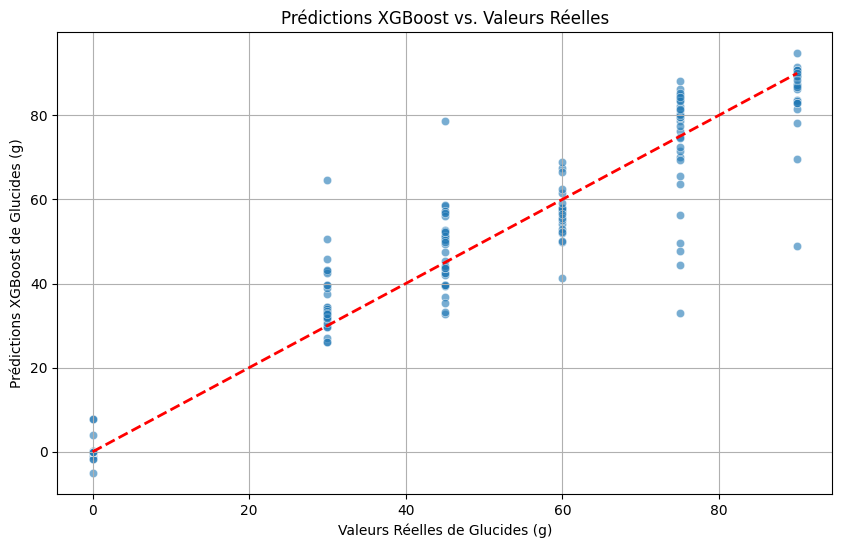

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ligne de prédiction parfaite
plt.xlabel("Valeurs Réelles de Glucides (g)")
plt.ylabel("Prédictions XGBoost de Glucides (g)")
plt.title("Prédictions XGBoost vs. Valeurs Réelles")
plt.grid(True)
plt.show()

#### 5.3.2 Recherche d'Hyperparamètres (Grid Search) pour XGBoost

Nous allons utiliser `GridSearchCV` pour trouver la meilleure combinaison d'hyperparamètres pour notre modèle XGBoost. Cela implique de définir une grille de paramètres à explorer et de laisser Scikit-learn tester systématiquement toutes les combinaisons en utilisant la validation croisée.

In [149]:
from sklearn.model_selection import GridSearchCV

# Définir la grille de paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],  # Nombre d'arbres
    'learning_rate': [0.01, 0.1, 0.2], # Taux d'apprentissage
    'max_depth': [3, 5, 7],         # Profondeur maximale de l'arbre
    'subsample': [0.7, 0.9, 1.0]     # Fraction des échantillons utilisés pour entraîner chaque arbre
}

# Initialiser le modèle XGBoost
xgb_model_gs = xgb.XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1) # n_jobs=-1 pour utiliser tous les cœurs disponibles

# Initialiser GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model_gs,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', # Utiliser MSE négatif car GridSearchCV maximise le score
    cv=3, # Utiliser 3-fold cross-validation
    verbose=1, # Afficher les progrès
    n_jobs=-1 # Utiliser tous les cœurs disponibles
)

# Exécuter la recherche sur grille sur les données d'entraînement
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres et le meilleur score
print("\nMeilleurs paramètres trouvés par Grid Search:")
print(grid_search.best_params_)

print("\nMeilleur score MSE (négatif) trouvé par Grid Search:")
print(f"{-grid_search.best_score_:.2f}") # Convertir le score négatif en MSE positif

# Obtenir le meilleur modèle
best_xgb_model = grid_search.best_estimator_

# Faire des prédictions avec le meilleur modèle
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Évaluer le meilleur modèle
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print(f"\nXGBoost (optimisé) - Erreur Quadratique Moyenne (MSE): {mse_best_xgb:.2f}")
print(f"XGBoost (optimisé) - Coefficient de Détermination (R2): {r2_best_xgb:.2f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Meilleurs paramètres trouvés par Grid Search:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}

Meilleur score MSE (négatif) trouvé par Grid Search:
4.57

XGBoost (optimisé) - Erreur Quadratique Moyenne (MSE): 3.85
XGBoost (optimisé) - Coefficient de Détermination (R2): 0.98


#### 5.4 LightGBM (Light Gradient Boosting Machine)

LightGBM est un framework de boosting de gradient distribué et à haute performance basé sur des algorithmes d'arbres de décision. Il est connu pour sa vitesse et son efficacité, en particulier sur de grands ensembles de données, et est une alternative populaire à XGBoost.

In [150]:
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Base Model: Linear Regression (Re-calculating to ensure consistency)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_lr)
r2_linear = r2_score(y_test, y_pred_lr)

# 2. LightGBM Model
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

# 3. Aggregating all results into metrics_df
results = {
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost (Défaut)', 'XGBoost (Optimisé)', 'LightGBM'],
    'MSE': [mse_linear, mse_rf, mse_xgb, mse_best_xgb, mse_lgb],
    'R2': [r2_linear, r2_rf, r2_xgb, r2_best_xgb, r2_lgb]
}

metrics_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print("\n--- Comparaison Finale des Performances (metrics_df) ---")
display(metrics_df)

# Visualisation de l'importance des caractéristiques pour le meilleur modèle (LightGBM)
print("\nImportance des caractéristiques (LightGBM):")
feature_importances_lgb = pd.Series(lgb_model.feature_importances_, index=X.columns)
display(feature_importances_lgb.sort_values(ascending=False).head(10))


--- Comparaison Finale des Performances (metrics_df) ---


,Modèle,MSE,R2
3,XGBoost (Optimisé),3.848889,0.976808
1,Random Forest,4.209924,0.974632
4,LightGBM,4.304759,0.974061
2,XGBoost (Défaut),4.918991,0.970360
0,Régression Linéaire,12.371634,0.925452



Importance des caractéristiques (LightGBM):


,0
insulin_bolus,516
glucose_lag1,220
glucose_diff2,178
gsr,159
heart_rate,158
carb_ratio,149
insulin_basal,139
glucose_rolling_mean_3,135
glucose_diff1,100
skin_temp,92


### 6. Création d'un Modèle Ensemble (Stacking)

Le **Stacking** combine plusieurs modèles de régression en utilisant leurs prédictions comme caractéristiques pour un modèle final (Meta-Regressor). Cela permet souvent de capturer des nuances que les modèles individuels pourraient manquer.

Entraînement du modèle Stacking (cela peut prendre un moment)...

--- Comparaison avec le modèle Stacking ---


,Modèle,MSE,R2
0,XGBoost (Optimisé),3.848889,0.976808
5,Stacking Ensemble,3.855336,0.976769
1,Random Forest,4.209924,0.974632
2,LightGBM,4.304759,0.974061
3,XGBoost (Défaut),4.918991,0.970360
4,Régression Linéaire,12.371634,0.925452


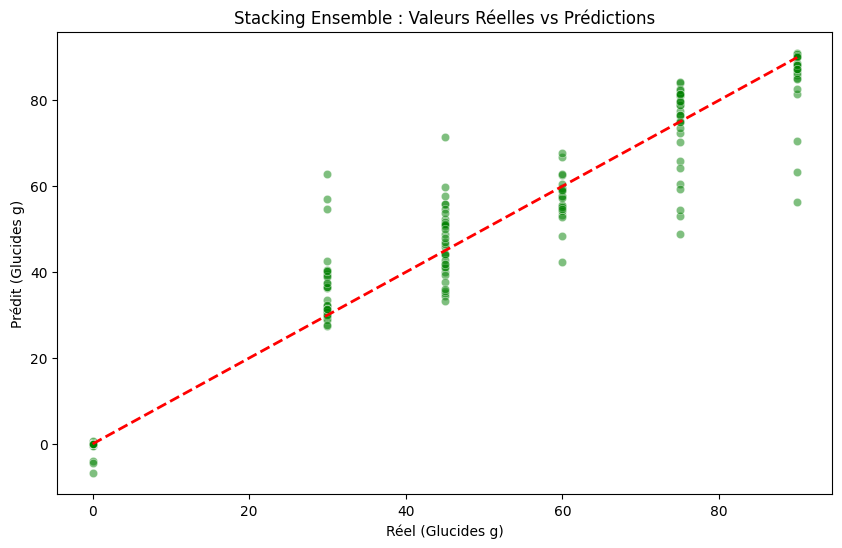

In [151]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Définir les modèles de base (ceux que nous avons déjà testés)
estimators = [
    ('rf', rf_model),
    ('xgb', best_xgb_model),
    ('lgb', lgb_model)
]

# Initialiser le Stacking Regressor avec une Régression Ridge comme méta-modèle
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

print("Entraînement du modèle Stacking (cela peut prendre un moment)...")
stacking_model.fit(X_train, y_train)

# Prédictions
y_pred_stack = stacking_model.predict(X_test)

# Évaluation
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

# Mise à jour du metrics_df
new_row = pd.DataFrame({
    'Modèle': ['Stacking Ensemble'],
    'MSE': [mse_stack],
    'R2': [r2_stack]
})

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True).sort_values(by='R2', ascending=False)

print("\n--- Comparaison avec le modèle Stacking ---")
display(metrics_df)

# Visualisation de la performance du Stacking
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_stack, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Stacking Ensemble : Valeurs Réelles vs Prédictions")
plt.xlabel("Réel (Glucides g)")
plt.ylabel("Prédit (Glucides g)")
plt.show()